<a href="https://colab.research.google.com/github/Sanjana-Munikrishnappa/ML_Saftey_Retrained/blob/ML-Saftey-Retrained/ML_Excercise_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mount Google Drive

Mounts your Google Drive to access files stored there, such as datasets and pre-trained models.

In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Import Necessary Libraries

Imports essential libraries for numerical operations (numpy), deep learning (torch), image processing (PIL, torchvision), and plotting (matplotlib).

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms

## Define Dataset Path and Inspect Contents

Sets the path to the CARLA dataset stored on Google Drive and lists the names of files and directories within that dataset to understand its structure.

In [ ]:
from pathlib import Path

dataset_path = Path("/content/drive/MyDrive/carla_dataset")

print([item.name for item in dataset_path.iterdir()])

['test.zip', 'train.zip', 'validation.zip', 'train', 'test', 'validation', 'test-fog.zip', 'test-night.zip', 'test-town-01.zip', 'traffic_light_model.pth', 'pedestrian_model.pth', 'vehicle_model.pth']


## Load Traffic Light Model State Dictionary (CPU)

Loads the state dictionary for the 'traffic_light_model.pth' file from Google Drive, specifying 'cpu' as the map location for compatibility.

In [ ]:
import torch
from pathlib import Path

model_file = Path("/content/drive/MyDrive/carla_dataset/traffic_light_model.pth")

state_dict = torch.load(model_file, map_location=torch.device("cpu"))

print(list(state_dict.keys()))

['model.0.weight', 'model.0.bias', 'model.3.weight', 'model.3.bias', 'model.6.weight', 'model.6.bias', 'model.10.weight', 'model.10.bias', 'model.12.weight', 'model.12.bias']


## Inspect Keys in Loaded State Dictionary

Iterates through the keys of the loaded state dictionary and prints them, providing insight into the layers and parameters stored in the pre-trained model.

In [ ]:
import torch
from pathlib import Path

model_path = Path("/content/drive/MyDrive/carla_dataset/traffic_light_model.pth")

state_dict = torch.load(model_path, map_location="cpu")

for key in state_dict:
    print(key)

model.0.weight
model.0.bias
model.3.weight
model.3.bias
model.6.weight
model.6.bias
model.10.weight
model.10.bias
model.12.weight
model.12.bias


## Examine Shapes of Weight Layers

Defines a list of keys corresponding to the weight layers in the model and then prints the shape of each weight tensor, useful for understanding the neural network architecture.

In [ ]:
weight_layers = [
    "model.0.weight",
    "model.3.weight",
    "model.6.weight",
    "model.10.weight",
    "model.12.weight"
]

for layer_name in weight_layers:
    print(state_dict[layer_name].shape)

torch.Size([16, 3, 3, 3])
torch.Size([32, 16, 3, 3])
torch.Size([64, 32, 3, 3])
torch.Size([128, 50176])
torch.Size([1, 128])


## Define Traffic Light Model and Load Pre-trained Weights

Defines the `TrafficLightModel` class, outlining the neural network architecture. Instantiates the model, loads the previously inspected state dictionary (`traffic_light_model.pth`), and sets the model to evaluation mode (`.eval()`).

In [ ]:
import torch
import torch.nn as nn

class TrafficLightModel(nn.Module):
    def __init__(self):
        super().__init__()

        layers = [
            nn.Conv2d(3, 16, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),

            nn.Flatten(),
            nn.Identity(),

            nn.Linear(50176, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        ]

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


traffic_light_model = TrafficLightModel()

model_path = "/content/drive/MyDrive/carla_dataset/traffic_light_model.pth"

state_dict = torch.load(
    model_path,
    map_location="cpu"
)

traffic_light_model.load_state_dict(state_dict)
traffic_light_model.eval()

print("Traffic Light Model Loaded Successfully")

Traffic Light Model Loaded Successfully


## Define Image Transformation for 128x128 Resolution

Creates a `torchvision.transforms.Compose` object to preprocess images. It resizes images to 128x128 pixels and converts them into PyTorch tensors.

In [ ]:
transform_128 = transforms.Compose(
    [
        transforms.Resize(size=(128, 128)),
        transforms.ToTensor()
    ]
)

## Extract Test Dataset and List Image Files

Extracts the 'test.zip' archive from Google Drive to the `/content/test` directory. It then identifies and sorts the image files within the extracted 'test' folder, printing the count and the name of the first image.

In [ ]:
from pathlib import Path
import zipfile

zip_path = Path("/content/drive/MyDrive/carla_dataset/test.zip")
extract_path = Path("/content/test")

with zipfile.ZipFile(zip_path) as archive:
    archive.extractall(extract_path)

image_folder = extract_path / "test"
files = sorted(item.name for item in image_folder.iterdir())

print("Number of images:", len(files))
print("First image:", files[0])

Number of images: 12
First image: .hydra


## Further Inspect Contents of the Extracted Test Folder

Lists the names of files and directories directly within the `/content/test/test` folder, providing a more granular view of the dataset's internal structure after extraction.

In [ ]:
from pathlib import Path

test_folder = Path("/content/test/test")

print([file.name for file in test_folder.iterdir()])

['carla.log', 'weather.feather', 'gnss.feather', 'sim.log', 'segmentation-front', 'actions.feather', 'rgb-front', '.hydra', 'labels.csv', 'labels.feather', 'collisions.feather', 'imu.feather']


## Recursive Inspection of Test Folder Structure

Recursively inspects the `/content/test/test` directory, printing each directory path and listing up to 5 subdirectories and 5 files within each, giving a comprehensive overview of the extracted data's organization.

In [ ]:
from pathlib import Path

test_root = Path("/content/test/test")

for current_path in sorted([p for p in test_root.rglob("*") if p.is_dir()]):
    subdirs = sorted([p.name for p in current_path.iterdir() if p.is_dir()])
    files = sorted([p.name for p in current_path.iterdir() if p.is_file()])

    print(current_path)
    print("dirs:", subdirs[:5])
    print("files:", files[:5])
    print("-------------")

/content/test/test/.hydra
dirs: []
files: ['config.yaml', 'hydra.yaml', 'overrides.yaml']
-------------
/content/test/test/rgb-front
dirs: []
files: ['000000.jpg', '000010.jpg', '000020.jpg', '000030.jpg', '000040.jpg']
-------------
/content/test/test/segmentation-front
dirs: []
files: ['000000.png', '000010.png', '000020.png', '000030.png', '000040.png']
-------------


## Count and Display RGB Front Images

Specifically targets the `rgb-front` subfolder within the extracted test data. Counts the number of JPEG image files and prints the total count along with the name of the first image.

In [ ]:
from pathlib import Path

image_folder = Path("/content/test/test/rgb-front")

files = sorted(file.name for file in image_folder.iterdir() if file.is_file())

print("Number of images:", len(files))
print("First image:", files[0])

Number of images: 3600
First image: 000000.jpg


## Visualize a Sample Image

Loads the first image identified in the `rgb-front` folder, converts it to RGB, and then displays it using Matplotlib for visual verification of image data.

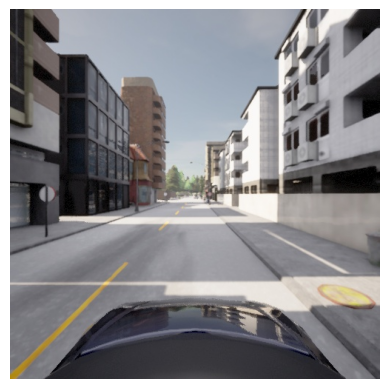

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

image_path = Path(image_folder) / files[0]
img = Image.open(image_path).convert("RGB")

plt.figure()
plt.imshow(img)
plt.axis("off")
plt.show()

## Get Image Dimensions

Retrieves and prints the width and height of the currently loaded sample image, providing information about its original resolution.

In [ ]:
width, height = img.size

print((width, height))

(500, 500)


## Define Image Transformation for 224x224 Resolution

Defines another `torchvision.transforms.Compose` pipeline, similar to `transform_128`, but this one resizes images to 224x224 pixels, which could be used for models expecting a different input size.

In [ ]:
from torchvision import transforms

transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

print(transform_224)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


## Assign and Display Current Transform Details

Assigns `transform_224` to a new variable `transform_details` and then prints its configuration, likely for debugging or to confirm the active transformation.

In [ ]:
transform_details = transform_224
print(transform_details)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


## Test Traffic Light Model on a Clean Image

Applies `transform_128` to the sample image, adds a batch dimension (`unsqueeze(0)`), and then uses the `traffic_light_model` to make a prediction. The output is converted to a probability using sigmoid and printed.

In [ ]:
input_tensor = transform_128(img).unsqueeze(0)

traffic_light_model.eval()

with torch.inference_mode():
    output = traffic_light_model(input_tensor)
    probability = output.sigmoid().item()

print("Probability:", probability)

Probability: 0.18286681175231934


## Define Fast Gradient Sign Method (FGSM) Attack

Defines the `fgsm_attack` function, which implements the Fast Gradient Sign Method for generating adversarial examples. It calculates the gradient of the loss with respect to the input image and perturbs the image in the direction of this gradient.

In [ ]:
import torch.nn.functional as F

def fgsm_attack(model, image, epsilon):
    adv_input = image.detach().clone()
    adv_input.requires_grad_(True)

    prediction = model(adv_input)

    target_label = torch.ones_like(prediction)

    loss = F.binary_cross_entropy_with_logits(
        prediction,
        target_label
    )

    model.zero_grad(set_to_none=True)
    loss.backward()

    gradient_sign = adv_input.grad.sign()
    adv_image = torch.clamp(
        adv_input + epsilon * gradient_sign,
        min=0,
        max=1
    )

    return adv_image.detach()

## Prepare Image Tensor for Adversarial Attack

Converts the sample image into a tensor suitable for the FGSM attack by applying `transform_128` and adding a batch dimension.

In [ ]:
img_tensor = transform_128(img).unsqueeze(0)

print("Image tensor shape:", img_tensor.shape)

Image tensor shape: torch.Size([1, 3, 128, 128])


## Generate Adversarial Image (Epsilon = 0.01)

Calls the `fgsm_attack` function to create an adversarial version of the image tensor with an epsilon value of 0.01, representing the perturbation strength.

In [ ]:
epsilon = 0.01

adv_img = fgsm_attack(
    model=traffic_light_model,
    image=img_tensor,
    epsilon=epsilon
)

print("Adversarial image generated")

Adversarial image generated


## Visualize Clean vs. Adversarial Image (Epsilon = 0.01)

Displays both the original (clean) image and the newly generated adversarial image (with epsilon=0.01) side-by-side using Matplotlib, allowing for a visual comparison of the perturbation.

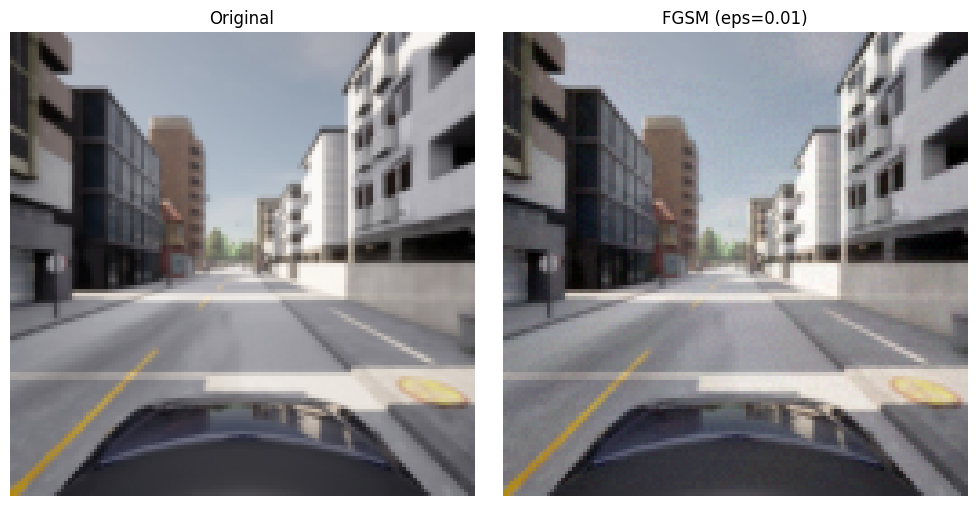

In [ ]:
import matplotlib.pyplot as plt

clean_image = img_tensor[0].permute(1, 2, 0).cpu().numpy()
adversarial_image = adv_img[0].detach().permute(1, 2, 0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

images = [clean_image, adversarial_image]
titles = ["Original", f"FGSM (eps={epsilon})"]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image)
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## Generate Adversarial Image (Epsilon = 0.05)

Generates another adversarial image using the `fgsm_attack` function, this time with a larger epsilon value of 0.05 to observe the effect of increased perturbation.

In [ ]:
epsilon = 0.05

adv_img_005 = fgsm_attack(
    model=traffic_light_model,
    image=img_tensor,
    epsilon=epsilon
)

print(f"Adversarial image generated for epsilon = {epsilon}")

Adversarial image generated for epsilon = 0.05


## Visualize Clean vs. Adversarial Image (Epsilon = 0.05)

Visualizes the original image and the adversarial image generated with epsilon=0.05, demonstrating the visual impact of the stronger perturbation.

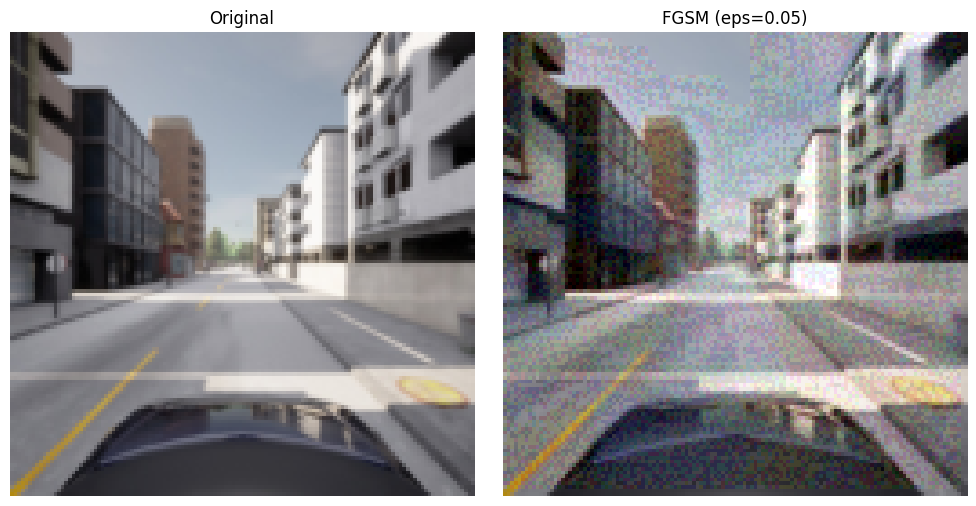

In [ ]:
import matplotlib.pyplot as plt

images = [
    img_tensor.squeeze().permute(1, 2, 0).numpy(),
    adv_img_005.squeeze().detach().permute(1, 2, 0).numpy()
]

titles = [
    "Original",
    "FGSM (eps=0.05)"
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for axis, image, title in zip(axes, images, titles):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()

## Compare Model Predictions: Clean vs. Adversarial (Epsilon = 0.05)

Evaluates the `traffic_light_model` on both the clean and the adversarial image (epsilon=0.05) and prints their respective probabilities, showing how the adversarial attack changes the model's output.

In [ ]:
with torch.inference_mode():
    clean_output = traffic_light_model(img_tensor)
    adversarial_output = traffic_light_model(adv_img_005)

clean_pred = clean_output.sigmoid().item()
adv_pred_005 = adversarial_output.sigmoid().item()

print("Clean probability :", clean_pred)
print("Adversarial probability (eps=0.05):", adv_pred_005)

Clean probability : 0.18286681175231934
Adversarial probability (eps=0.05): 0.0022157570347189903


## Generate Adversarial Image (Epsilon = 0.10)

Creates an adversarial image with an even larger epsilon value of 0.10, pushing the perturbation further.

In [ ]:
epsilon = 0.10

adv_img_010 = fgsm_attack(
    model=traffic_light_model,
    image=img_tensor,
    epsilon=epsilon
)

print(f"Adversarial image generated for epsilon = {epsilon}")

Adversarial image generated for epsilon = 0.1


## Visualize Clean vs. Adversarial Image (Epsilon = 0.10)

Displays the original image alongside the adversarial image generated with epsilon=0.10, highlighting the visual changes from a very strong perturbation.

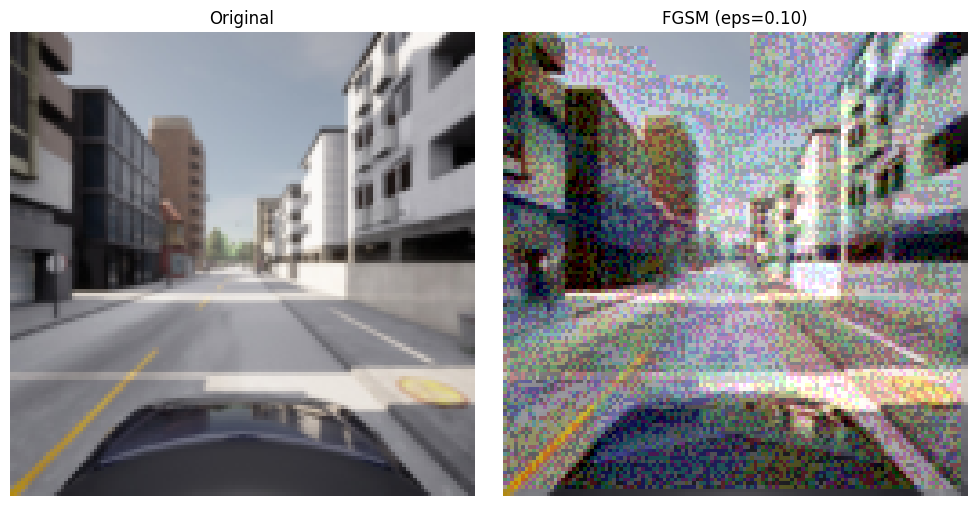

In [ ]:
import matplotlib.pyplot as plt

images = [
    img_tensor.squeeze(0).permute(1, 2, 0).numpy(),
    adv_img_010.squeeze(0).detach().permute(1, 2, 0).numpy()
]

titles = [
    "Original",
    "FGSM (eps=0.10)"
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image)
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## Compare Model Predictions: Clean vs. Adversarial (Epsilon = 0.10)

Evaluates the `traffic_light_model` on both the clean and the adversarial image (epsilon=0.10) and prints their respective probabilities, illustrating the model's vulnerability to significant perturbations.

In [ ]:
with torch.inference_mode():
    clean_output = traffic_light_model(img_tensor)
    adv_output_010 = traffic_light_model(adv_img_010)

clean_pred = clean_output.sigmoid().item()
adv_pred_010 = adv_output_010.sigmoid().item()

print("Clean probability :", clean_pred)
print("Adversarial probability (eps=0.10):", adv_pred_010)

Clean probability : 0.18286681175231934
Adversarial probability (eps=0.10): 9.548992238705978e-05


## Check if Models are Loaded into Global Scope

Verifies whether the `traffic_light_model`, `vehicle_model`, and `pedestrian_model` objects exist in the current global scope, confirming successful loading or instantiation.

In [ ]:
models = {
    "traffic_light_model": "traffic_light_model" in globals(),
    "vehicle_model": "vehicle_model" in globals(),
    "pedestrian_model": "pedestrian_model" in globals()
}

for name, exists in models.items():
    print(f"{name} exists:", exists)

traffic_light_model exists: True
vehicle_model exists: False
pedestrian_model exists: False


## Re-list Dataset Directory Contents

Re-lists the contents of the `carla_dataset` directory on Google Drive, confirming the presence of various zip files and pre-trained model files.

In [ ]:
from pathlib import Path

dataset_dir = Path("/content/drive/MyDrive/carla_dataset")

for item in dataset_dir.iterdir():
    print(item.name)

test.zip
train.zip
validation.zip
train
test
validation
test-fog.zip
test-night.zip
test-town-01.zip
traffic_light_model.pth
pedestrian_model.pth
vehicle_model.pth


## Define Vehicle Model and Load Pre-trained Weights

Defines the `VehicleModel` class, which has the same architecture as the traffic light model. It then loads the `vehicle_model.pth` weights and sets the model to evaluation mode.

In [ ]:
import torch
import torch.nn as nn


class VehicleModel(nn.Module):
    def __init__(self):
        super().__init__()

        architecture = [
            nn.Conv2d(3, 16, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),

            nn.Flatten(),
            nn.Identity(),

            nn.Linear(50176, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        ]

        self.model = nn.Sequential(*architecture)

    def forward(self, x):
        return self.model(x)


vehicle_model = VehicleModel()

model_path = "/content/drive/MyDrive/carla_dataset/vehicle_model.pth"

weights = torch.load(
    model_path,
    map_location=torch.device("cpu")
)

vehicle_model.load_state_dict(weights)
vehicle_model.eval()

print("Vehicle Model Loaded Successfully")

Vehicle Model Loaded Successfully


## Define Pedestrian Model and Load Pre-trained Weights

Defines the `PedestrianModel` class, again with an identical architecture. It loads the `pedestrian_model.pth` weights and sets the model to evaluation mode.

In [ ]:
import torch
import torch.nn as nn


class PedestrianModel(nn.Module):
    def __init__(self):
        super().__init__()

        layers = (
            nn.Conv2d(3, 16, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),

            nn.Flatten(),
            nn.Identity(),

            nn.Linear(50176, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        )

        self.model = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.model(inputs)


pedestrian_model = PedestrianModel()

model_path = "/content/drive/MyDrive/carla_dataset/pedestrian_model.pth"

weights = torch.load(
    model_path,
    map_location=torch.device("cpu")
)

pedestrian_model.load_state_dict(weights)
pedestrian_model.eval()

print("Pedestrian Model Loaded Successfully")

Pedestrian Model Loaded Successfully


## Verify All Three Models are Loaded

Explicitly checks and prints whether `traffic_light_model`, `vehicle_model`, and `pedestrian_model` are all successfully loaded and present in the global environment.

In [ ]:
model_names = [
    "traffic_light_model",
    "vehicle_model",
    "pedestrian_model"
]

for model_name in model_names:
    print(
        f"{model_name} exists:",
        model_name in globals()
    )

traffic_light_model exists: True
vehicle_model exists: True
pedestrian_model exists: True


In [ ]:
ve

## Identify Dataset-Related Variables

Iterates through all global variables and prints the names of those that contain "dataset" or "loader" in their lowercase names, helping to track data-related objects.

In [ ]:
current_variables = list(globals().items())

for variable_name, _ in current_variables:
    name_lower = variable_name.lower()

    if "dataset" in name_lower or "loader" in name_lower:
        print(variable_name)

__loader__
dataset_path
dataset_dir


## Assign and Print Current Image Transform

Assigns the `transform_128` object to a new variable named `transform` and then prints its details, making the `transform` variable available for subsequent use.

In [ ]:
transform = transform_128
print(transform)

Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


## Select a Subset of Images for Evaluation

Retrieves all image filenames from the `rgb-front` folder, shuffles them using a fixed random seed for reproducibility, and then selects 100 images to be used for model evaluation.

In [ ]:
from pathlib import Path
import random

image_folder = Path("/content/test/test/rgb-front")

all_images = sorted(
    file.name for file in image_folder.iterdir()
    if file.is_file()
)

rng = random.Random(42)
eval_images = rng.sample(all_images, 100)

print("Number of evaluation images:", len(eval_images))
print("First image:", eval_images[0])

Number of evaluation images: 100
First image: 026190.jpg


## Define Function for Evaluating Model Robustness

Defines the `evaluate_model_robustness` function. This function takes a model, a list of images, and an epsilon value, then calculates how many images the model classifies as positive (probability > 0.5) for both clean and adversarial examples.

In [ ]:
from PIL import Image
import torch
import os

def evaluate_model_robustness(model, image_list, epsilon):

    results = {
        "clean": 0,
        "adversarial": 0
    }

    for image_name in image_list:
        image_path = os.path.join(image_folder, image_name)

        image = Image.open(image_path).convert("RGB")
        input_tensor = transform_128(image).unsqueeze(0)

        with torch.inference_mode():
            clean_probability = model(input_tensor).sigmoid().item()

        if clean_probability > 0.5:
            results["clean"] += 1

        adversarial_tensor = fgsm_attack(
            model=model,
            image=input_tensor,
            epsilon=epsilon
        )

        with torch.inference_mode():
            adversarial_probability = model(
                adversarial_tensor
            ).sigmoid().item()

        if adversarial_probability > 0.5:
            results["adversarial"] += 1

    return results["clean"], results["adversarial"]

## Evaluate Traffic Light Model Robustness Across Epsilon Values

Iterates through different epsilon values (0.01, 0.05, 0.10) and calls `evaluate_model_robustness` for the `traffic_light_model`. It prints the clean positives, adversarial positives, and the 'Recall Drop' for each epsilon.

In [ ]:
epsilons = (0.01, 0.05, 0.10)

for epsilon_value in epsilons:

    clean_count, adversarial_count = evaluate_model_robustness(
        model=traffic_light_model,
        image_list=eval_images,
        epsilon=epsilon_value
    )

    print("\nTraffic Light Model")
    print("Epsilon:", epsilon_value)
    print("Clean positives:", clean_count)
    print("Adversarial positives:", adversarial_count)

    recall_drop = clean_count - adversarial_count

    print("Recall Drop:", recall_drop)


Traffic Light Model
Epsilon: 0.01
Clean positives: 65
Adversarial positives: 17
Recall Drop: 48

Traffic Light Model
Epsilon: 0.05
Clean positives: 65
Adversarial positives: 1
Recall Drop: 64

Traffic Light Model
Epsilon: 0.1
Clean positives: 65
Adversarial positives: 1
Recall Drop: 64


## Evaluate Vehicle Model Robustness Across Epsilon Values

Evaluates the `vehicle_model`'s robustness against FGSM attacks for the same set of epsilon values, printing the recall metrics.

In [ ]:
epsilons = (0.01, 0.05, 0.10)

for epsilon_value in epsilons:

    clean_count, adversarial_count = evaluate_model_robustness(
        model=vehicle_model,
        image_list=eval_images,
        epsilon=epsilon_value
    )

    print("\nVehicle Model")
    print("Epsilon:", epsilon_value)
    print("Clean positives:", clean_count)
    print("Adversarial positives:", adversarial_count)

    recall_drop = clean_count - adversarial_count

    print("Recall Drop:", recall_drop)


Vehicle Model
Epsilon: 0.01
Clean positives: 100
Adversarial positives: 69
Recall Drop: 31

Vehicle Model
Epsilon: 0.05
Clean positives: 100
Adversarial positives: 3
Recall Drop: 97

Vehicle Model
Epsilon: 0.1
Clean positives: 100
Adversarial positives: 2
Recall Drop: 98


## Evaluate Pedestrian Model Robustness Across Epsilon Values

Evaluates the `pedestrian_model`'s robustness against FGSM attacks for the defined epsilon values, displaying the clean and adversarial positive counts and the recall drop.

In [ ]:
epsilons = (0.01, 0.05, 0.10)

for epsilon_value in epsilons:

    clean_count, adversarial_count = evaluate_model_robustness(
        model=pedestrian_model,
        image_list=eval_images,
        epsilon=epsilon_value
    )

    print("\nPedestrian Model")
    print("Epsilon:", epsilon_value)
    print("Clean positives:", clean_count)
    print("Adversarial positives:", adversarial_count)

    recall_drop = clean_count - adversarial_count

    print("Recall Drop:", recall_drop)


Pedestrian Model
Epsilon: 0.01
Clean positives: 4
Adversarial positives: 1
Recall Drop: 3

Pedestrian Model
Epsilon: 0.05
Clean positives: 4
Adversarial positives: 0
Recall Drop: 4

Pedestrian Model
Epsilon: 0.1
Clean positives: 4
Adversarial positives: 0
Recall Drop: 4


## Load Test Labels from Feather File

Loads the `labels.feather` file, which contains ground truth labels for the test images, into a pandas DataFrame. It confirms successful loading, prints the number of labels, and displays the first few rows.

In [ ]:
import pandas as pd

test_labels_path = "/content/drive/MyDrive/carla_dataset/test/labels.feather"

test_labels = pd.read_feather(test_labels_path)

print("Test labels loaded successfully")
print("Number of labels:", len(test_labels))
print(test_labels.head())

Test labels loaded successfully
Number of labels: 3600
    frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0  000000              False           False        False                15   
1  000010               True           False         True               299   
2  000020               True           False         True               298   
3  000030               True           False         True               297   
4  000040               True           False         True               297   

   px_pedestrian  px_vehicle  
0              0          35  
1              0         116  
2              0         307  
3              0         258  
4              0         249  


## Analyze Value Counts for Key Label Columns

Iterates through the 'has_traffic_light', 'has_vehicle', and 'has_pedestrian' columns in the loaded labels DataFrame and prints the count of `True` and `False` values for each, providing a distribution of the labels.

In [ ]:
label_columns = [
    "has_traffic_light",
    "has_vehicle",
    "has_pedestrian"
]

for column in label_columns:
    print(column, "->", test_labels[column].value_counts().to_dict())

has_traffic_light -> {True: 2584, False: 1016}
has_vehicle -> {True: 2700, False: 900}
has_pedestrian -> {False: 2894, True: 706}


## Display All Available Columns in Label DataFrame

Simply prints a list of all column names present in the `test_labels` DataFrame, useful for quick reference of available label information.

In [ ]:
print("Available columns:")
print(test_labels.columns.tolist())

Available columns:
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']


## Re-confirm Label Columns

Re-prints the list of columns in the `test_labels` DataFrame, serving as a redundant check or reminder of the available labels.

In [ ]:
print("Label columns:")
print(test_labels.columns.tolist())

Label columns:
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']


## Inspect Label DataFrame: Head, Shape, and Data Types

Provides a quick overview of the `test_labels` DataFrame by printing its first few rows, its dimensions (shape), and the data type of each column. This is a standard initial data exploration step.

In [ ]:
print(test_labels.head())
print("\nShape:", test_labels.shape)
print("\nData types:")
print(test_labels.dtypes)

    frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0  000000              False           False        False                15   
1  000010               True           False         True               299   
2  000020               True           False         True               298   
3  000030               True           False         True               297   
4  000040               True           False         True               297   

   px_pedestrian  px_vehicle  
0              0          35  
1              0         116  
2              0         307  
3              0         258  
4              0         249  

Shape: (3600, 7)

Data types:
frame                object
has_traffic_light      bool
has_pedestrian         bool
has_vehicle            bool
px_traffic_light      int64
px_pedestrian         int64
px_vehicle            int64
dtype: object


## Identify Image Filename Column

Attempts to automatically detect the column in the `test_labels` DataFrame that contains image filenames. It checks for common column names like "image", "filename", or "frame" to identify the correct linking key.

In [ ]:
possible_name_columns = [
    "image",
    "image_name",
    "filename",
    "file_name",
    "name",
    "frame"
]

name_column = next(
    (col for col in possible_name_columns if col in test_labels.columns),
    None
)

print("Detected image column:", name_column)

Detected image column: frame


## Match Evaluation Images with Ground Truth Labels

Compares the `eval_images` (randomly selected images) with the filenames present in the `test_labels` DataFrame. It prints how many images from the evaluation set have corresponding entries in the labels, and how many are unmatched.

In [ ]:
if name_column is not None:
    label_names = set(test_labels[name_column].astype(str))

    matched_images = [
        image_name
        for image_name in eval_images
        if image_name in label_names
    ]

    print("Evaluation images:", len(eval_images))
    print("Matched images:", len(matched_images))
    print("Unmatched images:", len(eval_images) - len(matched_images))
else:
    print("Image filename column was not detected.")

Evaluation images: 100
Matched images: 0
Unmatched images: 100


## Create a Lookup for Ground Truth Labels

Creates a pandas DataFrame where the index is set to the image filenames (from the `name_column`) from `test_labels`. This makes it efficient to quickly retrieve ground truth labels for specific image files.

In [ ]:
label_lookup = test_labels.set_index(
    test_labels[name_column].astype(str)
)

print("Label lookup created successfully")

Label lookup created successfully


## Define Function to Calculate Recall for Adversarial Attacks

Defines the `calculate_recall` function. This function takes a model, a list of images, an epsilon value, and a target label column, then calculates the recall of the model's predictions on adversarial examples compared to the ground truth.

In [ ]:
def calculate_recall(model, image_list, epsilon, target_column):

    true_positive = 0
    false_negative = 0

    for image_name in image_list:

        if image_name not in label_lookup.index:
            continue

        ground_truth = int(label_lookup.loc[image_name, target_column])

        image_path = os.path.join(image_folder, image_name)

        image = Image.open(image_path).convert("RGB")
        image_tensor = transform_128(image).unsqueeze(0)

        with torch.inference_mode():
            clean_output = model(image_tensor)
            clean_probability = clean_output.sigmoid().item()

        adversarial_image = fgsm_attack(
            model=model,
            image=image_tensor,
            epsilon=epsilon
        )

        with torch.inference_mode():
            adversarial_output = model(adversarial_image)
            adversarial_probability = adversarial_output.sigmoid().item()

        adversarial_prediction = int(adversarial_probability > 0.5)

        if ground_truth == 1:
            if adversarial_prediction == 1:
                true_positive += 1
            else:
                false_negative += 1

    if true_positive + false_negative == 0:
        return 0.0

    return true_positive / (true_positive + false_negative)

## Calculate Clean Recalls for All Models

Iterates through the traffic light, vehicle, and pedestrian models. For each model, it calculates the recall on the clean (non-adversarial) images using the `calculate_recall` function with `epsilon=0.0` and stores the results.

In [ ]:
models_and_labels = {
    "Traffic Light": (traffic_light_model, "has_traffic_light"),
    "Vehicle": (vehicle_model, "has_vehicle"),
    "Pedestrian": (pedestrian_model, "has_pedestrian")
}

clean_recalls = {}

for model_name, (model, label_column) in models_and_labels.items():

    recall = calculate_recall(
        model=model,
        image_list=eval_images,
        epsilon=0.0,
        target_column=label_column
    )

    clean_recalls[model_name] = recall

    print(model_name)
    print("Clean Recall:", recall)
    print()

Traffic Light
Clean Recall: 0.0

Vehicle
Clean Recall: 0.0

Pedestrian
Clean Recall: 0.0



## Calculate Adversarial Recalls Across Epsilon Values

Calculates the adversarial recall for each model and for each specified epsilon value (0.01, 0.05, 0.10). It uses the `calculate_recall` function and stores the results in the `recall_results` dictionary.

In [ ]:
epsilons = [0.01, 0.05, 0.10]

recall_results = {}

for model_name, (model, label_column) in models_and_labels.items():

    recall_results[model_name] = {}

    for epsilon in epsilons:

        recall = calculate_recall(
            model=model,
            image_list=eval_images,
            epsilon=epsilon,
            target_column=label_column
        )

        recall_results[model_name][epsilon] = recall

        print(model_name)
        print("Epsilon:", epsilon)
        print("Adversarial Recall:", recall)
        print()

Traffic Light
Epsilon: 0.01
Adversarial Recall: 0.0

Traffic Light
Epsilon: 0.05
Adversarial Recall: 0.0

Traffic Light
Epsilon: 0.1
Adversarial Recall: 0.0

Vehicle
Epsilon: 0.01
Adversarial Recall: 0.0

Vehicle
Epsilon: 0.05
Adversarial Recall: 0.0

Vehicle
Epsilon: 0.1
Adversarial Recall: 0.0

Pedestrian
Epsilon: 0.01
Adversarial Recall: 0.0

Pedestrian
Epsilon: 0.05
Adversarial Recall: 0.0

Pedestrian
Epsilon: 0.1
Adversarial Recall: 0.0



## Display Detailed Recall Drop Information

Iterates through each model and epsilon value, printing the clean recall, adversarial recall, and the calculated recall drop. This provides a detailed view of how each model's performance degrades under adversarial attacks.

In [ ]:
for model_name in models_and_labels:

    clean_recall = clean_recalls[model_name]

    print("\n" + model_name)

    for epsilon in epsilons:

        adversarial_recall = recall_results[model_name][epsilon]

        recall_drop = clean_recall - adversarial_recall

        print("Epsilon:", epsilon)
        print("Clean Recall:", clean_recall)
        print("Adversarial Recall:", adversarial_recall)
        print("Recall Drop:", recall_drop)


Traffic Light
Epsilon: 0.01
Clean Recall: 0.0
Adversarial Recall: 0.0
Recall Drop: 0.0
Epsilon: 0.05
Clean Recall: 0.0
Adversarial Recall: 0.0
Recall Drop: 0.0
Epsilon: 0.1
Clean Recall: 0.0
Adversarial Recall: 0.0
Recall Drop: 0.0

Vehicle
Epsilon: 0.01
Clean Recall: 0.0
Adversarial Recall: 0.0
Recall Drop: 0.0
Epsilon: 0.05
Clean Recall: 0.0
Adversarial Recall: 0.0
Recall Drop: 0.0
Epsilon: 0.1
Clean Recall: 0.0
Adversarial Recall: 0.0
Recall Drop: 0.0

Pedestrian
Epsilon: 0.01
Clean Recall: 0.0
Adversarial Recall: 0.0
Recall Drop: 0.0
Epsilon: 0.05
Clean Recall: 0.0
Adversarial Recall: 0.0
Recall Drop: 0.0
Epsilon: 0.1
Clean Recall: 0.0
Adversarial Recall: 0.0
Recall Drop: 0.0


## Summarize Recall Results in a DataFrame

Consolidates all the calculated recall metrics (clean recall, adversarial recall, and recall drop for each model and epsilon) into a pandas DataFrame named `recall_summary` for easier analysis and presentation.

In [ ]:
import pandas as pd

summary = []

for model_name in models_and_labels:

    clean_recall = clean_recalls[model_name]

    for epsilon in epsilons:

        adversarial_recall = recall_results[model_name][epsilon]

        summary.append({
            "Model": model_name,
            "Epsilon": epsilon,
            "Clean Recall": clean_recall,
            "Adversarial Recall": adversarial_recall,
            "Recall Drop": clean_recall - adversarial_recall
        })

recall_summary = pd.DataFrame(summary)

print(recall_summary)

           Model  Epsilon  Clean Recall  Adversarial Recall  Recall Drop
0  Traffic Light     0.01           0.0                 0.0          0.0
1  Traffic Light     0.05           0.0                 0.0          0.0
2  Traffic Light     0.10           0.0                 0.0          0.0
3        Vehicle     0.01           0.0                 0.0          0.0
4        Vehicle     0.05           0.0                 0.0          0.0
5        Vehicle     0.10           0.0                 0.0          0.0
6     Pedestrian     0.01           0.0                 0.0          0.0
7     Pedestrian     0.05           0.0                 0.0          0.0
8     Pedestrian     0.10           0.0                 0.0          0.0
